<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Brand               5000 non-null   object 
 1   Model               5000 non-null   object 
 2   Year                5000 non-null   int64  
 3   Country             5000 non-null   object 
 4   Condition           5000 non-null   object 
 5   Engine_Size         5000 non-null   float64
 6   Horsepower          5000 non-null   int64  
 7   Torque              5000 non-null   int64  
 8   Weight              5000 non-null   int64  
 9   Top_Speed           5000 non-null   int64  
 10  Acceleration_0_100  5000 non-null   float64
 11  Fuel_Type           5000 non-null   object 
 12  Drivetrain          5000 non-null   object 
 13  Transmission        5000 non-null   object 
 14  Fuel_Efficiency     5000 non-null   float64
 15  CO2_Emissions       5000 non-null   int64  
 16  Price 

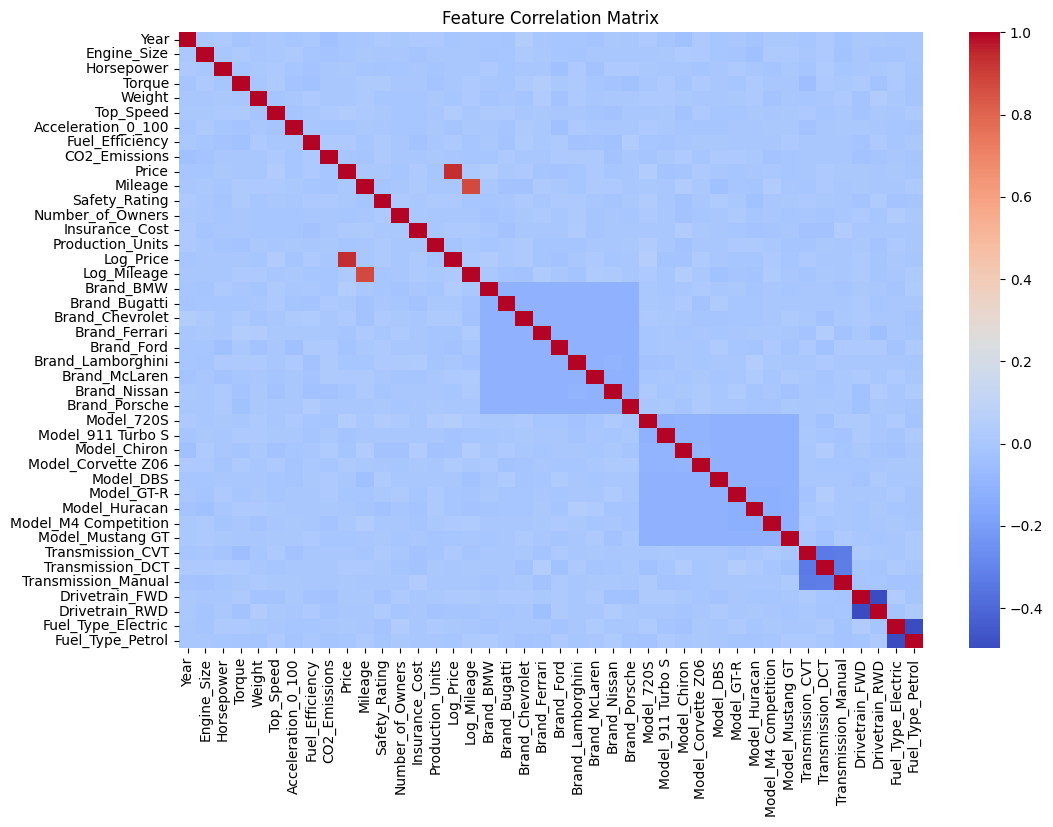

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

df=pd.read_csv('Elite Sports Cars in Data.csv')

print(df.info())
print(df.isnull().sum())

if df['Modification'].isnull().mean() > 0.5:
  df=df.drop('Modification',axis=1)
else:
  df['Modifiation'] = df['Modification'].fillna('None')

df = df.drop_duplicates()

categorical_cols = ['Brand', 'Model', 'Transmission', 'Drivetrain', 'Fuel_Type']
df=pd.get_dummies(df, columns=categorical_cols ,drop_first=True)

Q1 = df['Horsepower'].quantile(0.25)
Q3 = df['Horsepower'].quantile(0.75)

IQR = Q3 - Q1

df=df[(df['Horsepower'] >=Q1 -1.5 * IQR) & (df['Horsepower'] <= Q3+ 1.5 * IQR)]

scaler = StandardScaler()
numerical_cols = ['Engine_Size', 'Horsepower', 'Torque', 'Top_Speed', 'Acceleration_0_100','Fuel_Efficiency', 'CO2_Emissions', 'Mileage', 'Safety_Rating', 'Insurance_Cost' ,'Price']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.to_csv('elite_supercars_cleaned.csv', index =False)

# Drop non-numeric columns before calculating correlation
df_numeric = df.drop(columns=['Country', 'Condition', 'Popularity', 'Market_Demand'], errors='ignore')

import seaborn as sns
import matplotlib.pyplot as plt
corr = df_numeric.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()